  10.0   0.0000
  11.0   7.4129
  12.0  17.8962
  13.0  24.3564
  14.0  27.3424
  15.0  28.1050
  16.0  27.6539
  17.0  26.7784
  18.0  26.0689
  19.0  25.9373
  20.0  26.6388
  21.0  28.2921
  22.0  30.9014
  23.0  34.3766
  24.0  38.5549
  25.0  43.2216
  26.0  48.1313
  27.0  53.0286
  28.0  57.6697
  29.0  61.8429
  30.0  65.3902
  31.0  68.2277
  32.0  70.3673
  33.0  71.9372
  34.0  73.2033
  35.0  74.5902
  36.0  76.7022
  37.0  80.3442
  38.0  86.5429
  39.0  96.5680
  40.0 111.9530
  41.0 133.2533
  42.0 156.7312
  43.0 178.8567
  44.0 197.4974
  45.0 211.7212
  46.0 221.5987
  47.0 228.0063
  48.0 232.4287
  49.0 236.7616
  50.0 243.1144
  51.0 253.6134
  52.0 270.2036
  53.0 294.4523
  54.0 327.3513
  55.0 369.1199
  56.0 419.0073
  57.0 475.0958
  58.0 534.1029
  59.0 591.1847
  60.0 639.7380
  61.0 674.0553
  62.0 698.0892
  63.0 717.5269
  64.0 737.0912
  65.0 760.6038
  66.0 791.0497
  67.0 830.6407
  68.0 880.8795
  69.0 942.6236
  70.0 1016.1490
  71.0 1101.2142
  72.0

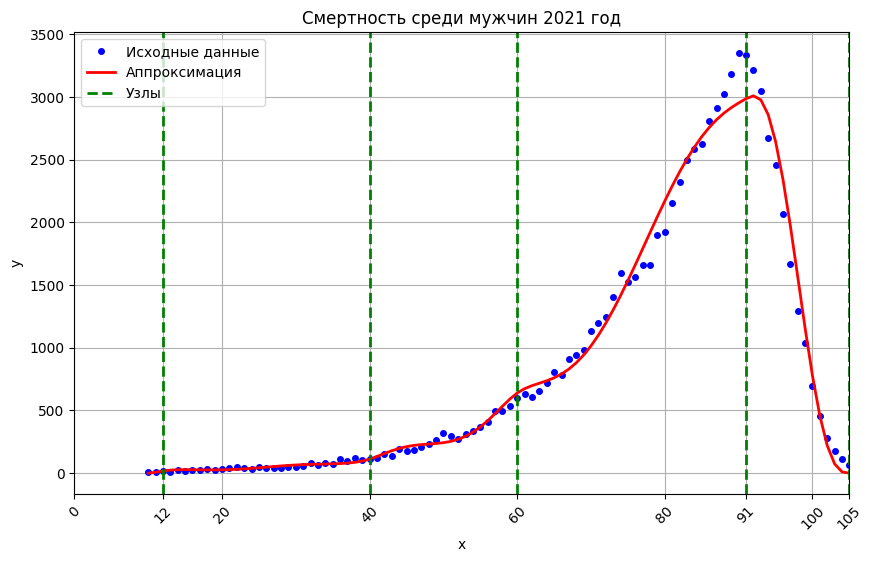

In [6]:
from typing import AsyncGenerator
import numpy as np
import matplotlib.pyplot as plt

# Базисные функции
def ph0(x):
    x2 = x ** 2
    x3 = x2 * x
    x4 = x3 * x
    x5 = x4 * x
    if x > 0:
        r = 1 - 10 * x3 + 15 * x4 - 6 * x5
    else:
        r = 1 + 10 * x3 + 15 * x4 + 6 * x5
    return r if abs(x) <= 1 else 0.0

def ph1(x):
    x2 = x ** 2
    x3 = x2 * x
    x4 = x3 * x
    x5 = x4 * x
    if x > 0:
        r = x * (1 - 6 * x2 + 8 * x3 - 3 * x4)
    else:
        r = x * (1 - 6 * x2 - 8 * x3 - 3 * x4)
    return r if abs(x) <= 1 else 0.0

def ph2(x):
    x2 = x ** 2
    x3 = x2 * x
    x4 = x3 * x
    x5 = x4 * x
    if x > 0:
        r = x2 - 3 * x3 + 3 * x4 - x5
    else:
        r = x2 + 3 * x3 + 3 * x4 + x5
    return r if abs(x) <= 1 else 0.0

# Метод Гаусса для решения СЛАУ
def gauss(nl, a, x):
    pl = list(range(nl))  # Массив перестановок строк
    sol = True
    for step in range(nl-1):
        abed = 0.0
        nbed = step
        # Поиск ведущего элемента
        for il in range(step, nl):
            current = abs(a[pl[il]][step])
            if current > abed:
                nbed = il
                abed = current
        if abed == 0.0:
            sol = False
            print("sol = false")
            return
        # Перестановка строк
        pl[step], pl[nbed] = pl[nbed], pl[step]
        # Исключение переменных
        for lin in range(step+1, nl):
            if a[pl[step]][step] == 0.0:
                continue  # Избегаем деления на ноль
            r = a[pl[lin]][step] / a[pl[step]][step]
            a[pl[lin]][step] = 0.0
            for st in range(step+1, nl+1):
                a[pl[lin]][st] -= a[pl[step]][st] * r
    # Обратный ход
    if sol:
        for lin in reversed(range(nl)):
            if a[pl[lin]][lin] == 0.0:
                continue  # Избегаем деления на ноль
            if lin == nl-1:
                x[lin] = a[pl[lin]][nl] / a[pl[lin]][lin]
            else:
                sum_val = sum(a[pl[lin]][k] * x[k] for k in range(lin+1, nl))
                x[lin] = (a[pl[lin]][nl] - sum_val) / a[pl[lin]][lin]

# Метод наименьших квадратов
def mnk(m, n, d, fi, x):
    aa = [[0.0]*(m+1) for _ in range(m)]
    for i in range(m):
        # Правая часть
        aa[i][m] = sum(d[l] * fi[i][l] for l in range(n))
        # Матрица системы
        for j in range(m):
            aa[i][j] = sum(fi[i][l] * fi[j][l] for l in range(n))
    # Решение СЛАУ
    gauss(m, aa, x)

# Основная программа
if __name__ == "__main__":
    # Чтение данных с заполнением недостающих температур нулями
    age_to_value = {}
    with open('Australia_Deaths_men_2021.txt', 'r') as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = list(map(float, line.split()))
            if len(parts) >= 2:
                age = int(round(parts[0]))  # Округляем до целого
                if 10 <= age <= 105:
                    age_to_value[age] = parts[1]

    # Формируем полные данные от -50 до 50
    x = list(range(10, 106))  # -50, -49, ..., 50
    y = [age_to_value.get(t, 0.0) for t in x]

    n = len(x)  # n = 101
    #Интервалы и шаги
    """
          1921 = [12, 38, 43, 75, 100]
          1941 = [12, 40, 49, 75, 100]
          1961 = [12, 40, 50, 78, 100]
          1981 = [12, 40, 50, 83, 100]
          2001 = [12, 40, 55, 86, 100]
          2021 = [12, 40, 60, 91, 105]
    """
    xx = [12, 40, 60, 91, 105]
    hh = [
        xx[1] - xx[0],  # hh[0] соответствует Pascal hh[1]
        xx[2] - xx[1],
        xx[3] - xx[2],
        xx[4] - xx[3]
    ]


    # Инициализация базисных функций
    fi = [[0.0]*n for _ in range(13)]  # 11 строк, n столбцов

    # Заполнение матрицы базисных функций
    for i in range(n):
        t = x[i]
        i1_pascal = 0
        if t < xx[i1_pascal]:
            h = hh[i1_pascal-1]
        else:
            h = hh[i1_pascal]
        # Первый элемент (Pascal fi[1,i])
        scaled_x = (t - xx[i1_pascal])/h
        fi[0][i] = ph0(scaled_x)
        fi[1][i] = h * ph1(scaled_x)
        fi[2][i] = h**2 * ph2(scaled_x)


        # Обработка интервала 1 (Pascal i1=1, j=2)
        i1_pascal = 1
        if t < xx[i1_pascal]:
            h = hh[i1_pascal-1]
        else:
            h = hh[i1_pascal]
        scaled_x = (t - xx[i1_pascal])/h
        fi[3][i] = ph0(scaled_x)
        fi[4][i] = h * ph1(scaled_x)
        fi[5][i] = h**2 * ph2(scaled_x)

        # Обработка интервала 2 (Pascal i1=2, j=5)
        i1_pascal = 2
        if t < xx[i1_pascal]:
            h = hh[i1_pascal-1]
        else:
            h = hh[i1_pascal]
        scaled_x = (t - xx[i1_pascal])/h
        fi[6][i] = ph0(scaled_x)
        fi[7][i] = h * ph1(scaled_x)
        fi[8][i] = h**2 * ph2(scaled_x)

        # Обработка интервала 3 (Pascal i1=3, j=8)
        i1_pascal = 3
        if t < xx[i1_pascal]:
            h = hh[i1_pascal-1]
        else:
            h = hh[i1_pascal]
        scaled_x = (t - xx[i1_pascal])/h
        fi[9][i] = ph0(scaled_x)
        fi[10][i] = h * ph1(scaled_x)
        fi[11][i] = h**2 * ph2(scaled_x)

        # Последний элемент (Pascal fi[1,i])
        fi[12][i] = hh[3]**2 * ph2((t - xx[4])/hh[3])

    # Решение МНК
    a = [0.0]*13
    mnk(11, n, y, fi, a)


    # Вычисление приближенных значений
    s_values = []
    for i in range(n):
        s = sum(a[j] * fi[j][i] for j in range(13))
        s = max(0.0, s)
        s_values.append(s)
        print(f"{x[i]:6.1f} {s:8.4f}")


    # with open('approximated_australia_deaths.txt', 'a') as out_file:
    #     for i in range(n):
    #         out_file.write(f"{x[i]:6.1f} {s_values[i]:8.4f} {2021}\n")


    # Построение графика
    plt.figure(figsize=(10, 6))
    plt.plot(x, y, 'o', label='Исходные данные', markersize=4, color='blue')
    plt.plot(x, s_values, '-', label='Аппроксимация', linewidth=2, color='red')
    plt.title('Смертность среди мужчин 2021 год')
    plt.xlabel('x')
    plt.ylabel('y')

    # Отметить узлы вертикальными линиями
    for node in xx:
        plt.axvline(x=node, color='green', linestyle='--', linewidth=2, label='Узлы' if node == xx[0] else "")

    # Убедиться, что узлы подписаны на оси X
    plt.xticks(sorted(set(plt.xticks()[0].tolist() + xx)),rotation=45)
    plt.legend()
    plt.grid(True)
    plt.xlim(0, 105)
    plt.savefig('least_squares_approcsimation_2021.png', dpi=300, bbox_inches='tight')
    plt.show()